# Ενδιάμεση Εργασία

Μπαρμπαγιάννος Βασίλειος

ΑΕΜ: 10685

Τμήμα Ηλεκτρολόγων Μηχανικών και Μηχανικών Υπολογιστών


# Εκφώνηση

Να γραφεί πρόγραμμα σε οποιαδήποτε γλώσσα επιθυμείτε το οποίο να συγκρίνει την απόδοση του
κατηγοριοποιητή πλησιέστερου γείτονα με 1 και 3 πλησιέστερους γείτονες με τον κατηγοριοποιητή
πλησιέστερου κέντρου στην βάση δεδομένων που θα επιλέξετε για την εργασία σας. Το πρόγραμμα
δηλαδή αυτό θα πρέπει να διαβάζει τα δεδομένα εκπαίδευσης (training) και τα δεδομένα ελέγχου (test)
και να μετράει την απόδοση των παραπάνω κατηγοριοποιητών.

# 1 Λήψη και εξαγωγή δεδομένων

In [1]:
# Κατεβάζουμε το CIFAR-100 dataset σε Python Version απευθείας μέσα στο Colab για να αποφύγουμε το χειροκίνητο upload.
!wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz

# Κάνουμε extract το αρχείο .tar.gz.
!tar -xvzf cifar-100-python.tar.gz


--2026-01-04 10:44:16--  https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 169001437 (161M) [application/x-gzip]
Saving to: ‘cifar-100-python.tar.gz’

cifar-100-python.ta 100%[===================>] 161.17M  13.8MB/s    in 14s     

2026-01-04 10:44:31 (11.9 MB/s) - ‘cifar-100-python.tar.gz’ saved [169001437/169001437]

cifar-100-python/
cifar-100-python/file.txt~
cifar-100-python/train
cifar-100-python/test
cifar-100-python/meta


# 2 Διαχωρισμός train και test data


In [2]:
"""
Το CIFAR-100 dataset είναι ένα archive που περιέχει τα files: data_batch_1, data_batch_2, ..., data_batch_5 και test_batch.
Κάθε file είναι ένα pickled object και ο κάτωθι κώδικας το ανοίγει και επιστρέφει ένα dictionary.
"""
import os
import pickle
import numpy as np

FILE = "cifar-100-python" # Το όνομα του φακέλου στον οποίο βρίσκεται το cifar-100 dataset.

def unpickle(path): # Η μέθοδος βρίσκεται στο link: https://www.cs.toronto.edu/~kriz/cifar.html.
    with open(path, 'rb') as f: # Ανοίγει ένα binary αρχείο για ανάγνωση.
        d = pickle.load(f, encoding='bytes') # Χρησιμοποιεί τη βιβλιοθήκη pickle για να φορτώσει τα δεδομένα σε μορφή dictionary.
                                             # Το dictionary έχει keys και values. Τα keys εδώ είναι bytes αντί για strings.
    return d # Επιστρέφει dictionary.

# Φορτώνω τα train και test datasets με τη μορφή dictionaries.
train_dict = unpickle(os.path.join(FILE, "train"))
test_dict  = unpickle(os.path.join(FILE, "test"))
meta_dict  = unpickle(os.path.join(FILE, "meta"))

# Εικόνες (είναι ήδη flatten, δηλαδή διανύσματα 1x3072 και όχι τριδιάστατοι πίνακες 32x32x3).
x_train = train_dict[b'data'] # Πίνακας διάστασης (50000, 3072).
y_train = np.array(train_dict[b'fine_labels'], dtype=np.int64) # Διάνυσμα διάστασης (50000,). Είναι μόνο τα labels.
                                                               # Μετατροπή λίστας σε numpy array με μέγεθος 64 bit.
x_test  = test_dict[b'data'] # Πίνακας διάστασης (10000, 3072).
y_test  = np.array(test_dict[b'fine_labels'], dtype=np.int64) # Διάνυσμα διάστασης (10000,). Μόνο τα labels.

# Τα ονόματα των κλάσεων στις οποίες ανήκουν οι εικόνες.
# To .decode('utf-8') μετατρέπει κάθε byte string σε string.
label_names = [name.decode('utf-8') for name in meta_dict[b'fine_label_names']]

# Τυπώνω το σχήμα των πινάκων και διανυσμάτων.
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)
# Τυπώνω και μερικά labels.
print("classes:", len(label_names), ":", label_names[:5])


x_train: (50000, 3072)
y_train: (50000,)
x_test : (10000, 3072)
y_test : (10000,)
classes: 100 : ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']


# 3 Κανονικοποίηση δεδομένων


In [3]:
# Μετατροπή σε 32 bit floating point. Κανονικοποίηση των δεδομένων διαιρώντας με τη μέγιστη τιμή pixel, το 255.
# Δηλαδή τα φέρνω στη (κοινή) κλίμακα [0, 1].
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32)  / 255.0

print("x_train range:", (x_train.min(), x_train.max()))
print("x_test  range:", (x_test.min(), x_test.max()))

x_train range: (np.float32(0.0), np.float32(1.0))
x_test  range: (np.float32(0.0), np.float32(1.0))


# 4 Ανασχηματισμός εικόνας


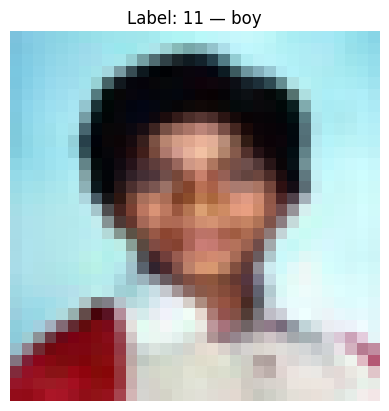

In [4]:
# Προαιρετικό: ανασχηματισμός εικόνας από flat διάνυσμα 1x3072 σε πίνακα 32x32x3.
import matplotlib.pyplot as plt

# Συνάρτηση που μετατρέπει flat διάνυσμα πίσω σε εικόνα, δηλαδή πίνακα 32x32x3.
def flat_to_img(row_flat):
    # flat vector (3072,) [Κανάλι κόκκινου χρώματος (1024), πράσινου (1024), μπλε (1024)].
    r = row_flat[0:1024].reshape(32, 32) # Το κάνω reshape σε 32x32 πίνακα.
    g = row_flat[1024:2048].reshape(32, 32)
    b = row_flat[2048:3072].reshape(32, 32)
    img = np.dstack([r, g, b]) # Πίνακας διάστασης 32x32x3. Στοιβάζω τους τρεις παραπάνω πίνακες κατά βάθος.
    return img

idx = 3
img = flat_to_img(x_train[idx])
plt.imshow(img)
plt.title(f"Label: {y_train[idx]} — {label_names[y_train[idx]]}")
plt.axis('off')
plt.show()

# 5 Εφαρμογή PCA


In [5]:
# Τώρα εφαρμόζω PCA και μειώνω τις διαστάσεις. Το PCA κεντράρει τα δεδομένα, δηλαδή αφαιρεί το μέσο.
# Τα κλιμάκωσα (κανονικοποίησα) ήδη στο προηγούμενο βήμα.

from sklearn.decomposition import PCA

# Πόσες συνιστώσες κρατάω.
N_COMPONENTS = 100 # 50 ή 100 συνιστώσες. Δοκιμάζω και το ένα και το άλλο.

# Ο randomized solver είναι πολύ πιο γρήγορος όταν οι διαστάσεις που κρατάω
# είναι πολύ λιγότερες από τη διάσταση του διανύσματος χαρακτηριστικών.
pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized', random_state=42)

# Fit ΜΟΝΟ στο train dataset. Αυτή η εντολή μαθαίνει τα principal components του διανύσματος x_train.
# Βρίσκει τη βάση, δηλαδή υπολογίζει τον pca μετασχηματισμό.
pca.fit(x_train)

"""
pca.fit() βρίσκω πως να κάνω μείωση διάστασης.
pca.transform() εφαρμόζω αυτή τη μείωση διάστασης.
"""

# Transform train/test με το ΙΔΙΟ PCA. Η εντολή pca.transform εφαρμόζει το μετασχηματισμό που έμαθε η pca.fit.
# Δεν ξανά υπολογίζω PCA μετασχηματισμό. Εφαρμόζω αυτόν που έμαθε από τα δεδομένα x_train.
# Δεν θέλω το PCA μοντέλο να δει τα x_test data.

# Προβάλω τα x_train και x_test data πάνω στη βάση που βρήκα.
x_train_pca = pca.transform(x_train) # Σχήμα: (50000, N_COMPONENTS).
x_test_pca  = pca.transform(x_test) # Σχήμα: (10000, N_COMPONENTS).

print("x_train_pca:", x_train_pca.shape)
print("x_test_pca :", x_test_pca.shape)

x_train_pca: (50000, 100)
x_test_pca : (10000, 100)


# 6 Πόσο καλά εξηγούν τα δεδομένα οι συνιστώσες που κράτησε το PCA


Explained variance with 300 components (δηλαδή διαστάσεις): 0.9673

Όσο πιο κοντά στη μονάδα, τόση περισσότερη πληροφορία έχω κρατήσει.


Στο συγκεκριμένο παράδειγμα, με τις 300 συνιστώσες κρατάω το 96.73% της πληροφορίας.



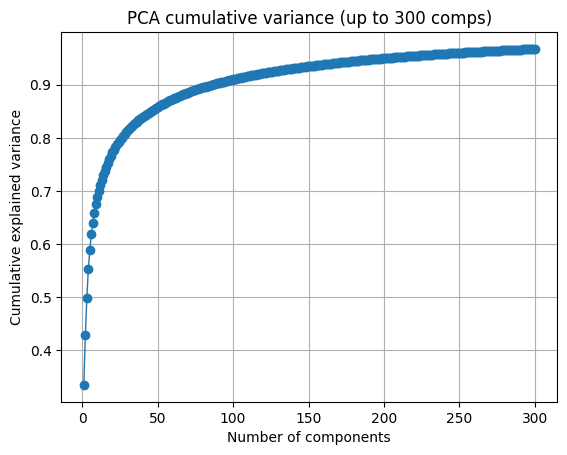

In [ ]:
# Εδώ βλέπω πόση πληροφορία κρατάω με τις συνιστώσες που έμειναν μετά την εφαρμογή του PCA μετασχηματισμού.

import numpy as np
import matplotlib.pyplot as plt

# Cumulative Variance Explained: πόση από τη μεταβλητότητα των αρχικών δεδομένων εξηγούν οι διαστάσεις που έβγαλε το PCA.
cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"Explained variance with {N_COMPONENTS} components (δηλαδή διαστάσεις): {cumvar[-1]:.4f}")
# cumvar[-1]: παίρνει την τελευταία τιμή.

print("\nΌσο πιο κοντά στη μονάδα, τόση περισσότερη πληροφορία έχω κρατήσει.\n")

print(f"\nΣτο συγκεκριμένο παράδειγμα, με τις {N_COMPONENTS} συνιστώσες κρατάω το {cumvar[-1]*100:.2f}% της πληροφορίας.\n")

plt.figure()
plt.plot(np.arange(1, N_COMPONENTS+1), cumvar, marker='o', linewidth=1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title(f'PCA cumulative variance (up to {N_COMPONENTS} comps)')
plt.grid(True)
plt.show()

# 7 Εισαγωγή ταξινομητών


In [ ]:
# Κάνω import τους ταξινομητές που θα χρειαστώ από την βιβλιοθήκη sklearn.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score

import time

def evaluate_classifier(model, x_train, y_train, x_test, y_test):
    """
    Εκπαίδευση ταξινομητή στο train set,
    πρόβλεψη στο test set,
    και επιστροφή accuracy καθώς και χρόνους εκπαίδευσης/πρόβλεψης.
    """
    t0 = time.time() # Ξεκινάω το χρονόμετρο.
    model.fit(x_train, y_train) # Εκπαιδεύω τον κάθε ταξινομητή.
    t1 = time.time() # Παίρνω μία μέτρηση.

    y_pred = model.predict(x_test) # Εκτελώ την πρόβλεψη.
    t2 = time.time() # Παίρνω ακόμη μία μέτρηση.

    accuracy = accuracy_score(y_test, y_pred) # Μετρώ την ακρίβεια.

    # Μετατροπή σε δευτερόλεπτα.
    fit_time = t1 - t0 # Χρόνος εκπαίδευσης.
    predict_time = t2 - t1 # Χρόνος πρόβλεψης.

    return accuracy, fit_time, predict_time # Επιστρέφω την ακρίβεια (accuracy) και χρόνους.


# 8 Εκπαίδευση και αξιολόγηση ταξινομητών


In [ ]:
# Εκπαίδευση και αξιολόγηση 1-ΝΝ, 3-ΝΝ και Nearest Centroid.

# Χρησιμοποιώ τα δεδομένα που προέκυψαν μετά την εφαρμογή PCA στο προηγούμενο βήμα.
# Τα μετονομάζω για καθαρότητα και σύντμηση.
Xtr, Ytr = x_train_pca, y_train
Xte, Yte = x_test_pca, y_test

# Ταξινομητής 1-NN.
knn1 = KNeighborsClassifier(n_neighbors=1) # Δημιουργία ταξινομητή.
acc_knn1, fit_t1, pred_t1 = evaluate_classifier(knn1, Xtr, Ytr, Xte, Yte) # Εκπαίδευση και αξιολόγηση.
print(f"1-NN: accuracy={acc_knn1:.4f} | train time={fit_t1:.2f}s | predict time={pred_t1:.2f}s")

# Ταξινομητής 3-NN.
knn3 = KNeighborsClassifier(n_neighbors=3)
acc_knn3, fit_t3, pred_t3 = evaluate_classifier(knn3, Xtr, Ytr, Xte, Yte)
print(f"3-NN: accuracy={acc_knn3:.4f} | train time={fit_t3:.2f}s | predict time={pred_t3:.2f}s")

# Ταξινομητής Nearest Centroid.
nc = NearestCentroid()
acc_nc, fit_tn, pred_tn = evaluate_classifier(nc, Xtr, Ytr, Xte, Yte)
print(f"Nearest Centroid: accuracy={acc_nc:.4f} | train time={fit_tn:.2f}s | predict time={pred_tn:.2f}s")

# Παρατηρώ ότι οι 1-ΝΝ και 3-ΝΝ ταξινομητές έχουν μεγαλύτερη ακρίβεια από
# τον Nearest Centroid.
# Ακόμη, ο 1-ΝΝ τα πάει καλύτερα όσων αφορά το accuracy σε σχέση με τον 3-NN.


1-NN: accuracy=0.1941 | train time=0.01s | predict time=6.14s
3-NN: accuracy=0.1630 | train time=0.01s | predict time=6.27s
Nearest Centroid: accuracy=0.1003 | train time=0.08s | predict time=0.02s


# 9 Γράφημα accuracy vs pca compontents



Running PCA with 10 components...

Running PCA with 25 components...

Running PCA with 50 components...

Running PCA with 75 components...

Running PCA with 100 components...

Running PCA with 150 components...

Running PCA with 200 components...


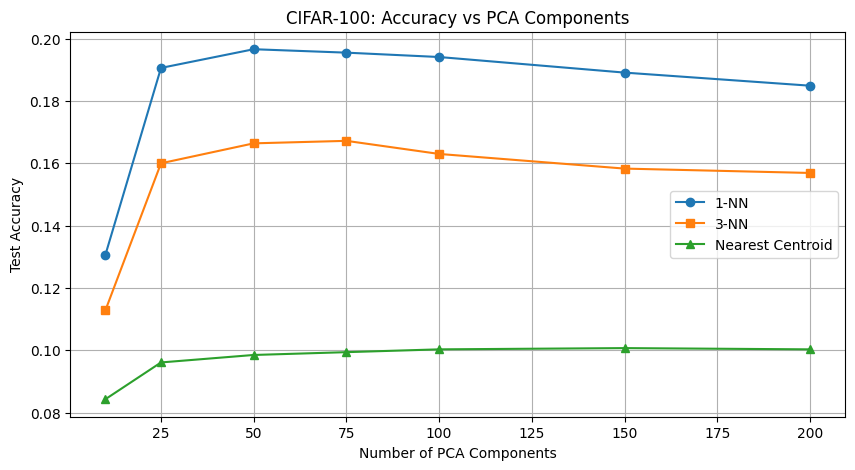

In [ ]:
# Σχεδιάζω γράφημα με το accuracy του κάθε ταξινομητή συναρτήσει του αριθμού των PCA συνιστωσών.

# Συγκεκριμένα, για κάθε αριθμό PCA συνιστωσών υπολογίζω το accuracy του κάθε ταξινομητή.

components_list = [10, 25, 50, 75, 100, 150, 200]

import matplotlib.pyplot as plt

components_list = [10, 25, 50, 75, 100, 150, 200]

# Τα accuracies θα αποθηκευτούν σε αυτές τις λίστες.
acc_knn1_list, fit_knn1_list, pred_knn1_list = [], [], []
acc_knn3_list, fit_knn3_list, pred_knn3_list = [], [], []
acc_nc_list, fit_nc_list, pred_nc_list = [], [], []

for n_components in components_list:
    print(f"\nRunning PCA with {n_components} components...")

    # Fit PCA στο train set
    pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
    pca.fit(x_train)

    # Transform both train and test.
    x_train_pca = pca.transform(x_train)
    x_test_pca = pca.transform(x_test)

    # 1-NN.
    knn1 = KNeighborsClassifier(n_neighbors=1)
    acc1, fit_t1, pred_t1 = evaluate_classifier(knn1, x_train_pca, y_train, x_test_pca, y_test)
    acc_knn1_list.append(acc1)
    fit_knn1_list.append(fit_t1)
    pred_knn1_list.append(pred_t1)

    # 3-NN.
    knn3 = KNeighborsClassifier(n_neighbors=3)
    acc3, fit_t3, pred_t3 = evaluate_classifier(knn3, x_train_pca, y_train, x_test_pca, y_test)
    acc_knn3_list.append(acc3)
    fit_knn3_list.append(fit_t3)
    pred_knn3_list.append(pred_t3)

    # Nearest Centroid.
    nc = NearestCentroid()
    accn, fit_tn, pred_tn = evaluate_classifier(nc, x_train_pca, y_train, x_test_pca, y_test)
    acc_nc_list.append(accn)
    fit_nc_list.append(fit_tn)
    pred_nc_list.append(pred_tn)

plt.figure(figsize=(10, 5))
plt.plot(components_list, acc_knn1_list, marker='o', label='1-NN')
plt.plot(components_list, acc_knn3_list, marker='s', label='3-NN')
plt.plot(components_list, acc_nc_list, marker='^', label='Nearest Centroid')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Accuracy')
plt.title('CIFAR-100: Accuracy vs PCA Components')
plt.legend()
plt.grid(True)
plt.show()

# 10 Εδώ θα συγκρίνω τις αποδόσεις των τριών ταξινομητών χωρίς εφαρμογή PCA


In [ ]:
import numpy as np

USE_SUBSET = False   # Βάλε False αν δεν θέλεις PCA. Βάλε True αν θέλεις PCA.
MAX_TRAIN = 20000   # π.χ. 20k από 50k. Χρησιμοποιώ μόνο τις 20.000 γραμμές του πίνακα, για ταχύτητα.
MAX_TEST  = 5000    # π.χ. 5k από 10k.
RNG = np.random.RandomState(42) # Για τυχαιότητα.

if USE_SUBSET:
    tr_idx = RNG.choice(x_train.shape[0], size=MAX_TRAIN, replace=False)
    te_idx = RNG.choice(x_test.shape[0],  size=MAX_TEST,  replace=False)
    Xtr_raw, Ytr_raw = x_train[tr_idx], y_train[tr_idx]
    Xte_raw, Yte_raw = x_test[te_idx],  y_test[te_idx]
else:
    Xtr_raw, Ytr_raw = x_train, y_train
    Xte_raw, Yte_raw = x_test,  y_test

Xtr_raw.shape, Xte_raw.shape, Ytr_raw.shape, Yte_raw.shape


((50000, 3072), (10000, 3072), (50000,), (10000,))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score
import time

def evaluate_classifier(model, Xtr, Ytr, Xte, Yte, name="model"):
    # Training (fit) time.
    t0 = time.perf_counter()
    model.fit(Xtr, Ytr)
    fit_s = time.perf_counter() - t0

    # Prediction (predict) time.
    t1 = time.perf_counter()
    y_pred = model.predict(Xte)
    pred_s = time.perf_counter() - t1

    # Accuracy.
    acc = accuracy_score(Yte, y_pred)

    print(f"{name}: accuracy={acc:.4f} | train time={fit_s:.2f}s | predict time={pred_s:.2f}s")

    return acc, fit_s, pred_s

# 1-NN.
knn1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
acc_knn1_raw, fit1_raw, pred1_raw = evaluate_classifier(knn1, Xtr_raw, Ytr_raw, Xte_raw, Yte_raw, name="1-NN (no PCA)")

# 3-NN.
knn3 = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
acc_knn3_raw, fit3_raw, pred3_raw = evaluate_classifier(knn3, Xtr_raw, Ytr_raw, Xte_raw, Yte_raw, name="3-NN (no PCA)")

# Nearest Centroid.
nc = NearestCentroid()
acc_nc_raw, fitn_raw, predn_raw = evaluate_classifier(nc, Xtr_raw, Ytr_raw, Xte_raw, Yte_raw, name="Nearest Centroid (no PCA)")

# Τα accuracy για έκαστο ταξινομητή είναι αυτά που φαίνονται.
# Είναι ελάχιστα μικρότερα από την περίπτωση που χρησιμοποιώ PCA.
# Συμπέρασμα: το PCA δεν βελτίωσε αισθητά το accuracy. Απλώς επιτάχυνε την ταξινόμηση.
# Πιθανή αιτία: οι εικόνες του cifar-100 είναι ποικιλόμορφες, δηλαδή περιέχουν πολλά και διάφορα pixels.
# Οπότε εμφανίζουν περίπλοκες διαχωριστικές επιφάνειες. Και οι ταξινομητές είναι αδύναμοι και μπερδεύονται.
# Δεν είναι τόσο "έξυπνοι" όπως τα συνελικτικά μοντέλα νευρωνικών δικτύων (Convolutional Neural Networks - CNN).


1-NN (no PCA): accuracy=0.1755 | train time=0.17s | predict time=132.08s
3-NN (no PCA): accuracy=0.1479 | train time=0.08s | predict time=132.64s
Nearest Centroid (no PCA): accuracy=0.1004 | train time=3.35s | predict time=0.56s


# 11 Εδώ κάνω το ίδιο με CIFAR-10 για να συγκρίνω τις αποδόσεις (accuracy)


In [ ]:
# Κατεβάζουμε το CIFAR-10 dataset σε Python Version απευθείας μέσα στο Colab για να αποφύγουμε το χειροκίνητο upload.
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

# Κάνουμε extract το αρχείο .tar.gz.
!tar -xvzf cifar-10-python.tar.gz


--2025-11-09 17:06:00--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz.3’

cifar-10-python.tar 100%[===================>] 162.60M  66.6MB/s    in 2.4s    

2025-11-09 17:06:02 (66.6 MB/s) - ‘cifar-10-python.tar.gz.3’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [ ]:

"""
Ακολουθώ την ίδια διαδικασία και με το CIFAR-10 dataset.
"""

import pickle
import numpy as np

def load_cifar10_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        data = batch[b'data']
        labels = batch[b'labels']
        return data, labels

x_train_list = []
y_train_list = []

for i in range(1, 6):
    data, labels = load_cifar10_batch(f'cifar-10-batches-py/data_batch_{i}')
    x_train_list.append(data)
    y_train_list.extend(labels)

x_train = np.vstack(x_train_list)
y_train = np.array(y_train_list)

x_test, y_test = load_cifar10_batch('cifar-10-batches-py/test_batch')
x_test = np.array(x_test)
y_test = np.array(y_test)

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


x_train: (50000, 3072), x_test: (10000, 3072)
y_train: (50000,), y_test: (10000,)


In [ ]:

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [ ]:
import os, pickle, numpy as np

FILE = "cifar-10-batches-py"

def load_cifar10_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        X = batch[b'data']
        y = np.array(batch[b'labels'])
        return X, y

# 5 training batches.
x_train_list, y_train_list = [], []
for i in range(1, 6):
    Xb, yb = load_cifar10_batch(os.path.join(FILE, f"data_batch_{i}"))
    x_train_list.append(Xb)
    y_train_list.append(yb)
x_train = np.vstack(x_train_list).astype(np.float32) / 255.0
y_train = np.concatenate(y_train_list)

x_test, y_test = load_cifar10_batch(os.path.join(FILE, "test_batch"))
x_test = x_test.astype(np.float32) / 255.0

with open(os.path.join(FILE, "batches.meta"), 'rb') as f:
    meta = pickle.load(f, encoding='bytes')
label_names = [n.decode("utf-8") for n in meta[b'label_names']]

print("x_train:", x_train.shape, "x_test:", x_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("labels:", label_names)


x_train: (50000, 3072) x_test: (10000, 3072)
y_train: (50000,) y_test: (10000,)
labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



PCA with 10 components

PCA with 25 components

PCA with 50 components

PCA with 75 components

PCA with 100 components

PCA with 150 components

PCA with 200 components


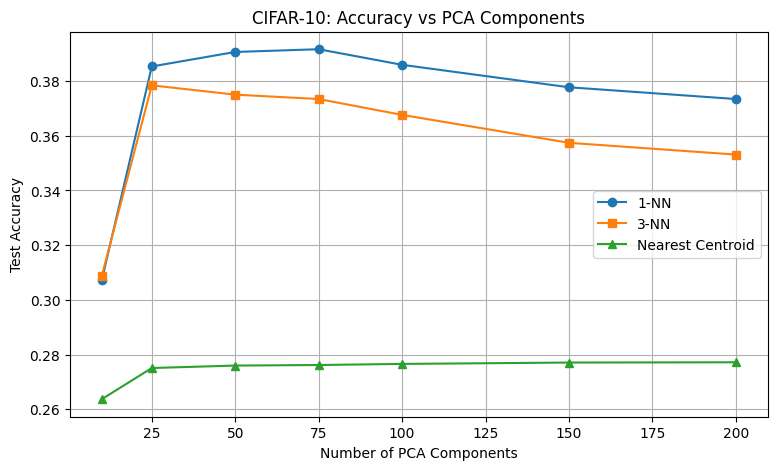


Best so far: 1-NN @ 75 comps — accuracy=0.3916


In [ ]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def evaluate(model, Xtr, Ytr, Xte, Yte):
    model.fit(Xtr, Ytr)
    y_pred = model.predict(Xte)
    return accuracy_score(Yte, y_pred), y_pred

components_list = [10, 25, 50, 75, 100, 150, 200]

acc_knn1_list, acc_knn3_list, acc_nc_list = [], [], []
best = {"acc": -1, "n": None, "name": None, "y_pred": None} # χρήση στο Confusion Matrix.

for n_components in components_list:
    print(f"\nPCA with {n_components} components")
    pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
    pca.fit(x_train)
    Xtr_pca = pca.transform(x_train)
    Xte_pca = pca.transform(x_test)

    # 1-NN.
    knn1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
    acc1, ypred1 = evaluate(knn1, Xtr_pca, y_train, Xte_pca, y_test)
    acc_knn1_list.append(acc1)
    if acc1 > best["acc"]:
        best = {"acc": acc1, "n": n_components, "name": "1-NN", "y_pred": ypred1}

    # 3-NN.
    knn3 = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
    acc3, ypred3 = evaluate(knn3, Xtr_pca, y_train, Xte_pca, y_test)
    acc_knn3_list.append(acc3)
    if acc3 > best["acc"]:
        best = {"acc": acc3, "n": n_components, "name": "3-NN", "y_pred": ypred3}

    # Nearest Centroid.
    nc = NearestCentroid()
    accnc, yprednc = evaluate(nc, Xtr_pca, y_train, Xte_pca, y_test)
    acc_nc_list.append(accnc)
    if accnc > best["acc"]:
        best = {"acc": accnc, "n": n_components, "name": "Nearest Centroid", "y_pred": yprednc}

plt.figure(figsize=(9,5))
plt.plot(components_list, acc_knn1_list, marker='o', label='1-NN')
plt.plot(components_list, acc_knn3_list, marker='s', label='3-NN')
plt.plot(components_list, acc_nc_list,  marker='^', label='Nearest Centroid')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Accuracy')
plt.title('CIFAR-10: Accuracy vs PCA Components')
plt.grid(True)
plt.legend()
plt.show()

best_preds = best["y_pred"]
best_n = best["n"]
best_name = best["name"]


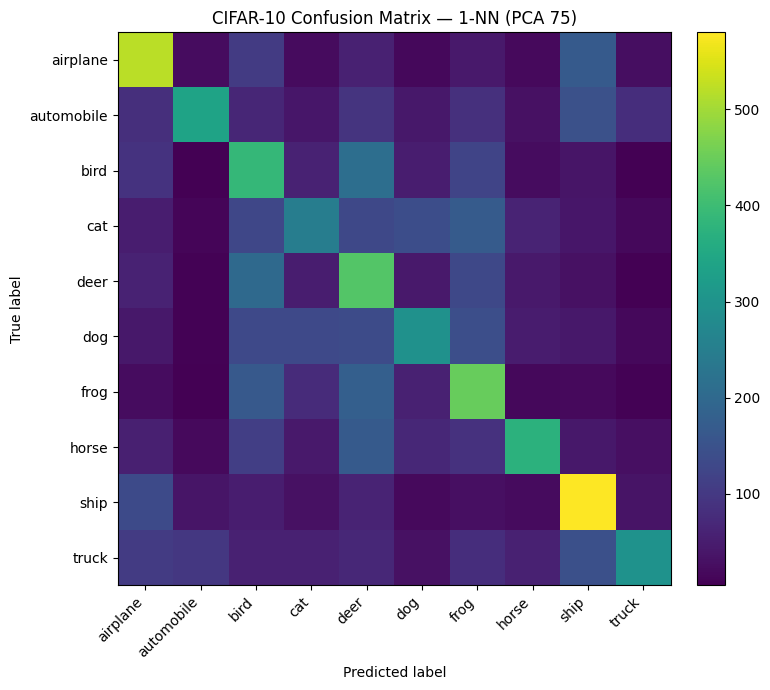

    airplane: 0.521
  automobile: 0.338
        bird: 0.389
         cat: 0.249
        deer: 0.426
         dog: 0.295
        frog: 0.446
       horse: 0.374
        ship: 0.580
       truck: 0.298

Macro average accuracy: 0.3916


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(8,7))
im = plt.imshow(cm, interpolation='nearest')
plt.title(f"CIFAR-10 Confusion Matrix — {best_name} (PCA {best_n})")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

per_class_acc = (cm.diagonal() / cm.sum(axis=1))
for i, acc in enumerate(per_class_acc):
    print(f"{label_names[i]:>12s}: {acc:.3f}")
print(f"\nMacro average accuracy: {per_class_acc.mean():.4f}")


In [ ]:
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score
import time

def evaluate_timed(model, Xtr, Ytr, Xte, Yte):
    t0 = time.perf_counter()
    model.fit(Xtr, Ytr)
    fit_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(Xte)
    pred_s = time.perf_counter() - t1

    acc = accuracy_score(Yte, y_pred)
    return acc, fit_s, pred_s

# 1-NN.
knn1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
acc1, fit1, pred1 = evaluate_timed(knn1, x_train, y_train, x_test, y_test)
print(f"1-NN (no PCA): accuracy={acc1:.4f} | train time={fit1:.2f}s | predict time={pred1:.2f}s")

# 3-NN.
knn3 = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
acc3, fit3, pred3 = evaluate_timed(knn3, x_train, y_train, x_test, y_test)
print(f"3-NN (no PCA): accuracy={acc3:.4f} | train time={fit3:.2f}s | predict time={pred3:.2f}s")

# Nearest Centroid.
nc = NearestCentroid()
accn, fitn, predn = evaluate_timed(nc, x_train, y_train, x_test, y_test)
print(f"Nearest Centroid (no PCA): accuracy={accn:.4f} | train time={fitn:.2f}s | predict time={predn:.2f}s")


1-NN (no PCA): accuracy=0.3539 | train time=2.66s | predict time=148.18s
3-NN (no PCA): accuracy=0.3303 | train time=0.07s | predict time=126.80s
Nearest Centroid (no PCA): accuracy=0.2774 | train time=3.23s | predict time=0.22s
